# ___

# [ Machine Learning in Geosciences ]

### | Topic: **GeoAI: Spatial Sampling of ST_LUCAS vector data for Spatial Cross-validation** 

### | Thematic focus: land cover 

.....................................................................................................................

Author: *Lukas Brodsky* *lukas.brodsky@natur.cuni.cz* 

Project: ESF pro VŠ II na UK | Reg. číslo: CZ.02.2.69/0.0/0.0/18_056/0013322

---

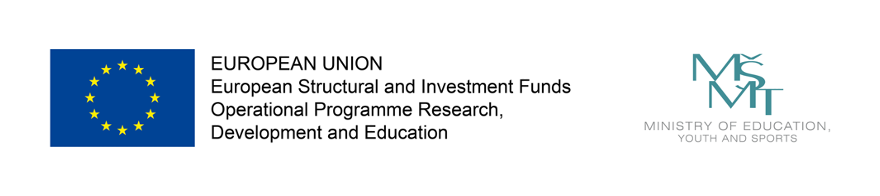

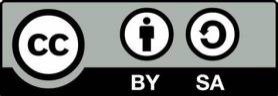

## Spatial Sampling 

using K-Means clusterring and random and spatial resampling (spatial-kfold Python package). 

    1. Spatial clustering with KMeans
    2. Spatial Blocks
        2.1 Spatial resampled random blocks     
        2.2 Continuous spatial resampled blocks
    3. Plotting function 

In [1]:
print(1)

1


In [ ]:
# spatial k-fold package 
# !pip install spatial-kfold

In [3]:
import os
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

from spatialkfold.blocks import spatial_blocks 
from spatialkfold.datasets import load_ames
from spatialkfold.clusters import spatial_kfold_clusters 
from spatialkfold.plotting import spatial_kfold_plot
from spatialkfold.stats import spatial_kfold_stats

In [4]:
os.listdir()

['07_1_LAB_GeoPython_rasterio.ipynb',
 '07_2_LAB_mlgeo_GeoPython_vector_spatial_sampling.ipynb',
 '17_3_LAB_Land_Cover_LUCAS_exercise.ipynb',
 'data']

In [5]:
# Load ST_LUCAS data
# https://drive.google.com/file/d/13FoS6gVEf-jo2CmeyLrpT5-TG7yx5qlv/view?usp=drive_link

path = './data'
lucas_fn = os.path.join(path, 'cz_lucas_points_2018.gpkg')
lucas = gpd.read_file(lucas_fn)

c:\Python_programming\ML_course\.venv\lib\site-packages\pyogrio\geopandas.py:382: UserWarning: More than one layer found in 'cz_lucas_points_2018.gpkg': 'lucas_points_lc_lu' (default), 'layer_styles'. Specify layer parameter to avoid this warning.
  result = read_func(


In [6]:
lucas.head(5)

,point_id,nuts0,nuts1,nuts2,nuts3,survey_date,car_latitude,car_longitude,car_ew,gps_proj,...,photo_point,photo_north,photo_east,photo_south,photo_west,crop_residues,transect,ex_ante,survey_year,geometry
0,46142892,CZ,CZ0,CZ03,CZ031,2018-07-18,49.069319,14.011057,1,1,...,1,1,1,1,1,2,None,0,2018,POINT (4614000.337 2891999.157)
1,48462894,CZ,CZ0,CZ06,CZ064,2018-05-15,48.928761,17.175367,1,1,...,1,1,1,1,1,2,None,0,2018,POINT (4845999.938 2894003.572)
2,48042992,CZ,CZ0,CZ05,CZ053,2018-06-22,49.840966,16.724575,1,1,...,1,1,1,1,1,1,None,0,2018,POINT (4804000.378 2991999.535)
3,46142990,CZ,CZ0,CZ02,CZ020,2018-08-13,49.948833,14.080428,1,1,...,1,1,1,1,1,2,None,0,2018,POINT (4613999.413 2989999.524)
4,46582898,CZ,CZ0,CZ03,CZ031,2018-07-23,49.099955,14.616137,1,1,...,1,1,1,1,1,-1,None,0,2018,POINT (4657999.519 2897999.834)


<Axes: >

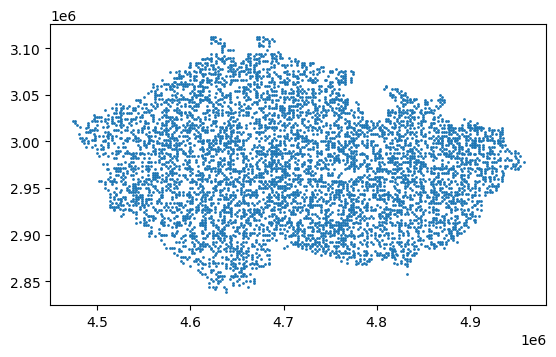

In [7]:
lucas.plot(markersize=1)

In [8]:
lucas.crs

<Projected CRS: EPSG:3035>
Name: ETRS89-extended / LAEA Europe
Axis Info [cartesian]:
- Y[north]: Northing (metre)
- X[east]: Easting (metre)
Area of Use:
- name: Europe - European Union (EU) countries and candidates. Europe - onshore and offshore: Albania; Andorra; Austria; Belgium; Bosnia and Herzegovina; Bulgaria; Croatia; Cyprus; Czechia; Denmark; Estonia; Faroe Islands; Finland; France; Germany; Gibraltar; Greece; Hungary; Iceland; Ireland; Italy; Kosovo; Latvia; Liechtenstein; Lithuania; Luxembourg; Malta; Monaco; Montenegro; Netherlands; North Macedonia; Norway including Svalbard and Jan Mayen; Poland; Portugal including Madeira and Azores; Romania; San Marino; Serbia; Slovakia; Slovenia; Spain including Canary Islands; Sweden; Switzerland; Türkiye (Turkey); United Kingdom (UK) including Channel Islands and Isle of Man; Vatican City State.
- bounds: (-35.58, 24.6, 44.83, 84.73)
Coordinate Operation:
- name: Europe Equal Area 2001
- method: Lambert Azimuthal Equal Area
Datum: Eur

## 1. Spatial clustering with KMeans

In [16]:
# 1. Spatial cluster resampling 
lucas_clusters = spatial_kfold_clusters(gdf=lucas, name='point_id', nfolds=200, 
                                       algorithm='kmeans', random_state=42) 


In [17]:
lucas_clusters.head(3)

,point_id,nuts0,nuts1,nuts2,nuts3,survey_date,car_latitude,car_longitude,car_ew,gps_proj,...,photo_north,photo_east,photo_south,photo_west,crop_residues,transect,ex_ante,survey_year,geometry,folds
0,46142892,CZ,CZ0,CZ03,CZ031,2018-07-18,49.069319,14.011057,1,1,...,1,1,1,1,2,None,0,2018,POINT (4614000.337 2891999.157),16
1,48462894,CZ,CZ0,CZ06,CZ064,2018-05-15,48.928761,17.175367,1,1,...,1,1,1,1,2,None,0,2018,POINT (4845999.938 2894003.572),173
2,48042992,CZ,CZ0,CZ05,CZ053,2018-06-22,49.840966,16.724575,1,1,...,1,1,1,1,1,None,0,2018,POINT (4804000.378 2991999.535),36


In [18]:
lucas_clusters["folds"].unique()

array([ 16, 173,  36,  34, 149, 163, 162,  99, 178, 197,  70,  88, 180,
        61,  81, 124,  58, 115, 104,  35,  37, 153, 119,  31, 185, 199,
       141, 116, 171, 134,  87,  32,  33, 158,  90,  26, 177, 148,   8,
        65, 175, 105,  27, 114, 121,  11, 169, 127,  40,  23,  57, 200,
        78, 132,  56,  18, 157,  76, 100,  64, 193,   3, 164, 113,  51,
       186,  55,  44,  20,  53,  17,  85, 191, 152, 139, 189, 140,   9,
        94,  69,   1,  42,  29, 196, 151, 154, 130,  60, 160,  48, 133,
        22,  75,  97, 123, 155,  68, 102,  28,  86,  83, 144,  91, 137,
       118,   4,  93, 181,  52,  12, 195, 122, 161,  13,   7, 194, 146,
       106,  82, 125,   6, 138, 168,   2,  43,  73,   5,  41, 129,  50,
       108, 135, 174, 110,  66, 188,  92, 111, 112,  95, 126, 117,  24,
       103,  10, 182,  21,  84, 183, 159,  74, 179,  79,  15,  98,  47,
       131, 167,  59, 142,  89,  71, 156,  96,  19,  80, 176, 192, 101,
       109, 165, 190,  25,  67,  54, 145, 147, 172,  62,  38, 15

In [19]:
# Plot with colors 
cols_tab = cm.get_cmap('tab20', 10)
cols = [cols_tab(i) for i in range(10)]
color_ramp = ListedColormap(cols)

C:\Users\Oleksandr\AppData\Local\Temp\ipykernel_28988\2426815093.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cols_tab = cm.get_cmap('tab20', 10)


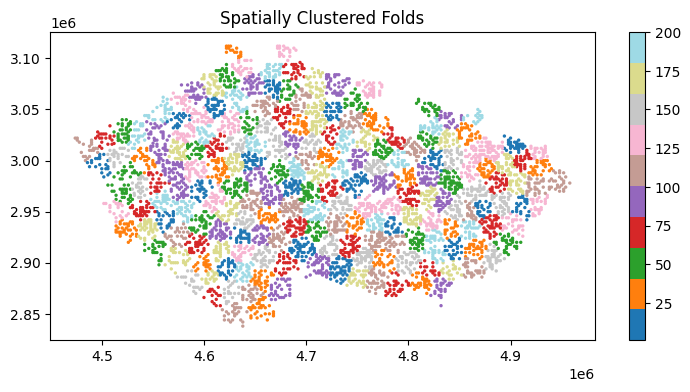

In [20]:
# Plot 
fig, ax = plt.subplots(1,1 , figsize=(9, 4)) 
lucas_clusters.plot(column='folds', ax=ax, cmap= color_ramp, markersize = 2, legend=True)
ax.set_title('Spatially Clustered Folds')
plt.show()

In [21]:
# check the number of train and test of the dependent variable for each fold
# lc1 attribute .. LUCAS Land Cover classification 
lucas_clusters_stats = spatial_kfold_stats(X=lucas_clusters, y= lucas_clusters.lc1, 
                                          groups = lucas_clusters.folds)

In [22]:
lucas_clusters_stats

,split,train,test
0,1,5689,24
1,2,5688,25
2,3,5686,27
3,4,5692,21
4,5,5682,31
...,...,...,...
195,196,5685,28
196,197,5690,23
197,198,5675,38
198,199,5687,26


## 2. Spatial Blocks

### 2.1 spatial resampled random blocks  

In [23]:
# create 10 random blocks 
lucas_rnd_blocks = spatial_blocks(gdf=lucas, width=25000, height=25000, 
                                 method='random', nfolds=10, 
                                 random_state=42)

In [24]:
lucas_rnd_blocks.head()

,geometry,folds
15,"POLYGON ((4573992.424 2888000, 4573992.424 291...",1
94,"POLYGON ((4773992.424 2863000, 4773992.424 288...",1
152,"POLYGON ((4973992.424 2963000, 4973992.424 298...",1
105,"POLYGON ((4798992.424 2913000, 4798992.424 293...",1
109,"POLYGON ((4798992.424 3013000, 4798992.424 303...",1


Text(0.5, 1.0, 'Random Blocks Folds')

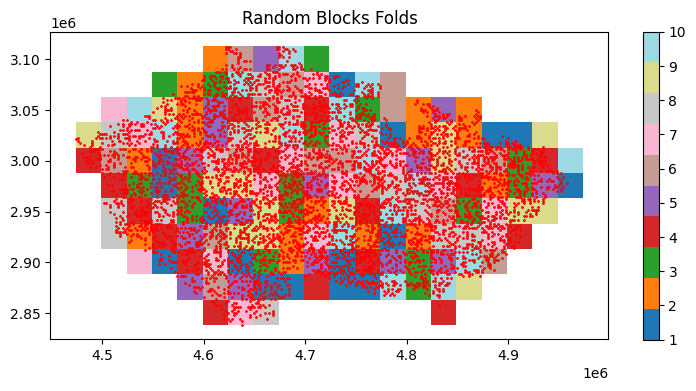

In [25]:
fig, ax = plt.subplots(1,1 , figsize=(9, 4)) 

lucas_rnd_blocks.plot(column = 'folds',cmap = color_ramp, ax = ax ,lw=0.7, legend = True)
lucas.plot(ax=ax,  markersize = 1, color = 'r')
ax.set_title('Random Blocks Folds')

In [ ]:
# Resample the data with the prepared blocks 

In [28]:
lucas_res_rnd_blk = gpd.overlay(lucas, lucas_rnd_blocks)

In [29]:
lucas_res_rnd_blk.head(3)

,point_id,nuts0,nuts1,nuts2,nuts3,survey_date,car_latitude,car_longitude,car_ew,gps_proj,...,photo_north,photo_east,photo_south,photo_west,crop_residues,transect,ex_ante,survey_year,folds,geometry
0,46142892,CZ,CZ0,CZ03,CZ031,2018-07-18,49.069319,14.011057,1,1,...,1,1,1,1,2,None,0,2018,7,POINT (4614000.337 2891999.157)
1,48462894,CZ,CZ0,CZ06,CZ064,2018-05-15,48.928761,17.175367,1,1,...,1,1,1,1,2,None,0,2018,5,POINT (4845999.938 2894003.572)
2,48042992,CZ,CZ0,CZ05,CZ053,2018-06-22,49.840966,16.724575,1,1,...,1,1,1,1,1,None,0,2018,5,POINT (4804000.378 2991999.535)


Text(0.5, 1.0, 'Spatially Resampled\nRandom Blocks')

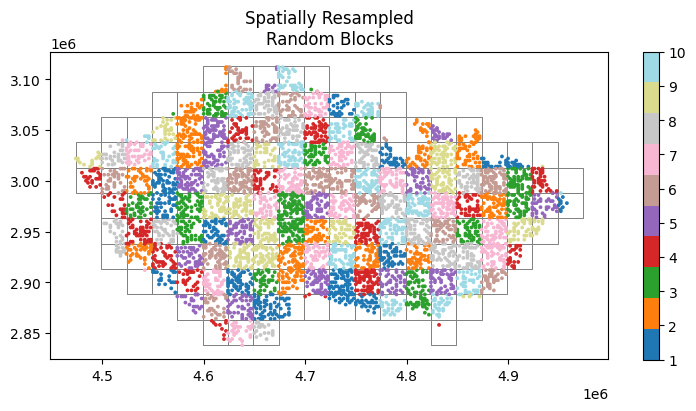

In [30]:
# plot the resampled blocks
fig, ax = plt.subplots(1,1 , figsize=(9, 4)) 

lucas_rnd_blocks.plot(facecolor="none",edgecolor='grey', ax = ax ,lw=0.7)
lucas_res_rnd_blk.plot(column = 'folds', cmap = color_ramp,legend = True, ax = ax, markersize = 3)
ax.set_title('Spatially Resampled\nRandom Blocks')

In [31]:

lucas_res_rnd_blk_stats = spatial_kfold_stats(X=lucas_res_rnd_blk, y= lucas_res_rnd_blk.lc1, 
                                             groups = lucas_res_rnd_blk.folds)


In [32]:
lucas_res_rnd_blk_stats

,split,train,test
0,1,5212,532
1,2,5142,602
2,3,5101,643
3,4,5224,520
4,5,5137,607
5,6,5160,584
6,7,5147,597
7,8,5154,590
8,9,5237,507
9,10,5182,562


### 2.2 Continuous spatial resampled blocks
Two option are availble with orientation :

'tb-lr' : top-bottom, left-right

'bt-rl' : bottom-top, right-left

In [33]:
lucas_cont_blocks = spatial_blocks(gdf=lucas, width=25000, height=25000, 
                                  method='continuous', orientation='tb-lr' ,
                                  nfolds=10, random_state=42)

Text(0.5, 1.0, 'Continuous Blocks Folds\norientation:"tb-lr"')

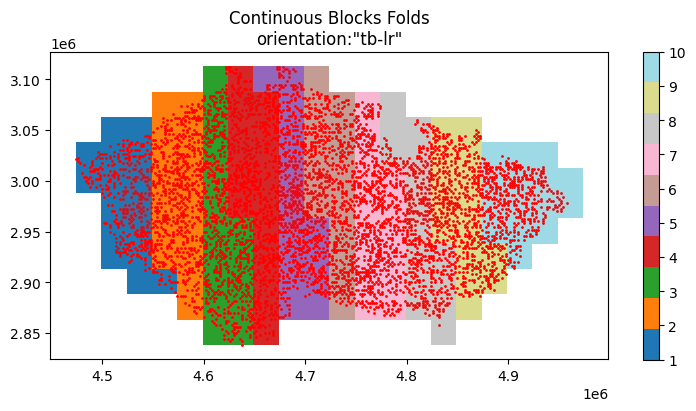

In [34]:
fig, ax = plt.subplots(1,1 , figsize=(9, 4)) 

lucas_cont_blocks.plot(column = 'folds',cmap = color_ramp, ax = ax ,lw=0.7, legend = True)
lucas.plot(ax=ax,  markersize = 1, color = 'r')
ax.set_title('Continuous Blocks Folds\norientation:"tb-lr"')

In [35]:
# resample the ames data with the prepared blocks 
lucas_res_cont_blk = gpd.overlay(lucas, lucas_cont_blocks)

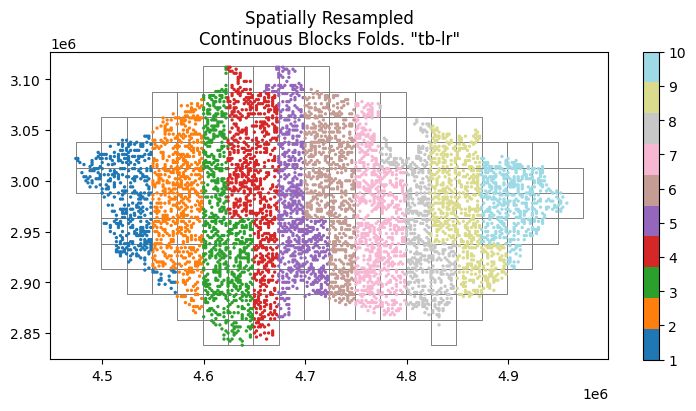

In [36]:
fig, ax = plt.subplots(1,1 , figsize=(9, 4)) 

lucas_cont_blocks.plot(facecolor="none",edgecolor='grey', ax = ax ,lw=0.7)
lucas_res_cont_blk.plot(column = 'folds', cmap = color_ramp,legend = True, ax = ax, markersize = 2)
ax.set_title('Spatially Resampled\nContinuous Blocks Folds. "tb-lr"')
plt.show()

In [37]:
lucas_res_cont_blk_stats = spatial_kfold_stats(X=lucas_res_cont_blk, y=lucas_res_cont_blk.lc1, 
                                              groups=lucas_res_cont_blk.folds)

In [38]:
lucas_res_cont_blk_stats

,split,train,test
0,1,5349,395
1,2,5151,593
2,3,5105,639
3,4,5067,677
4,5,5127,617
5,6,5129,615
6,7,5081,663
7,8,5268,476
8,9,5137,607
9,10,5282,462


## 3. Plotting function
Plot the partitioning of the data at each fold

In [39]:
# check the folds number 
np.unique(lucas_clusters.folds.values)

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169,
       170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 18

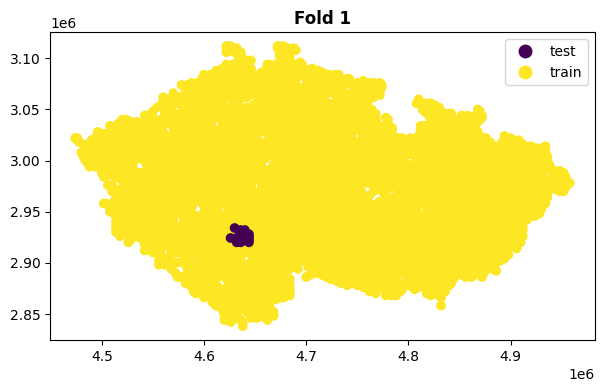

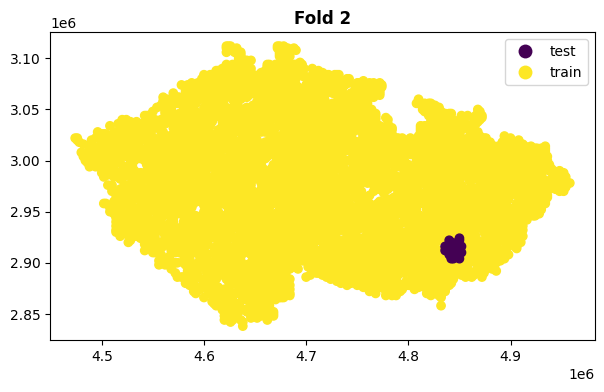

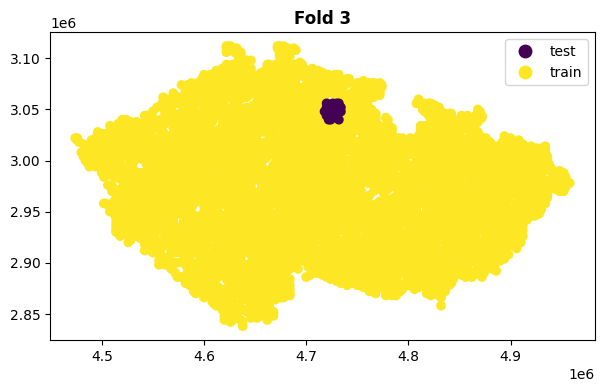

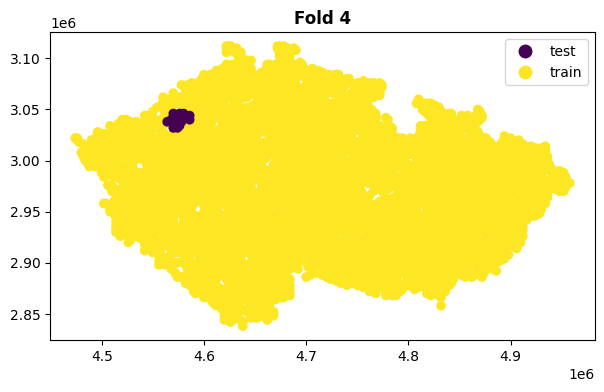

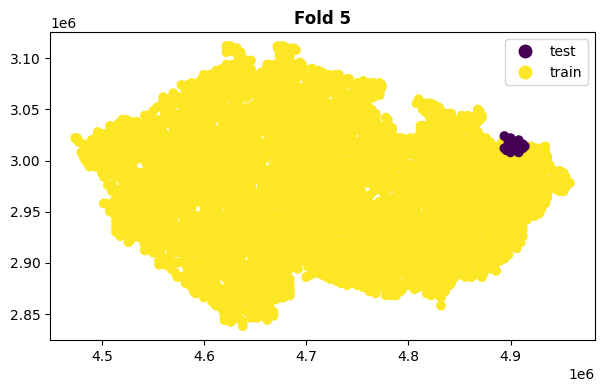

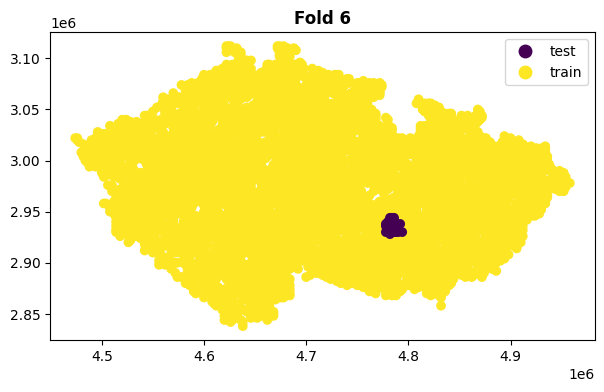

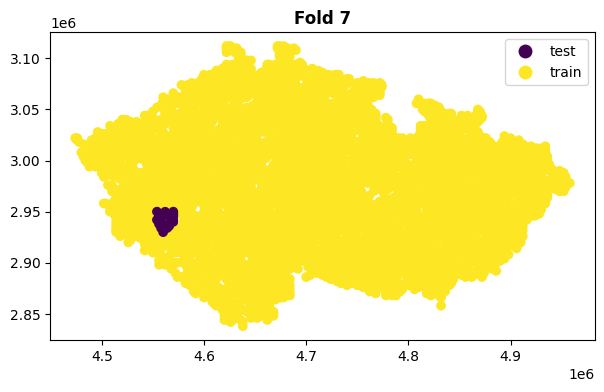

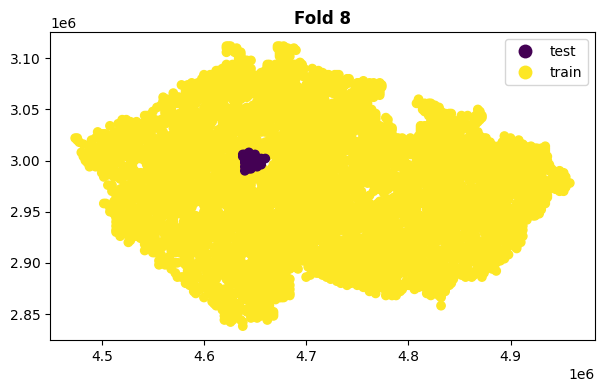

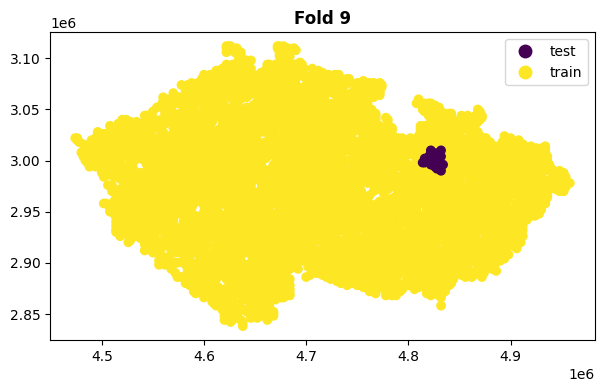

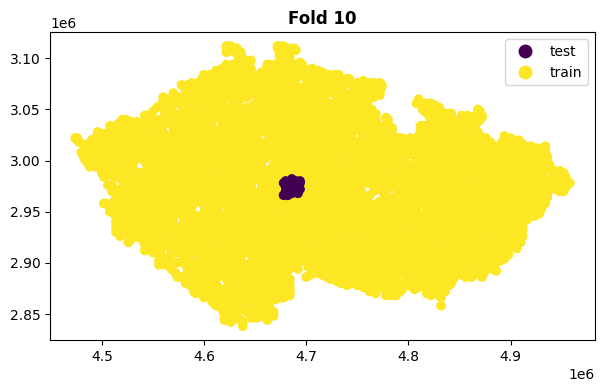

In [40]:
for i in range(1,11):
    fig, ax = plt.subplots(1,1 , figsize=(9, 4))

    spatial_kfold_plot(X=lucas_clusters, 
                       geometry=lucas_clusters.geometry, 
                       groups=lucas_clusters.folds, 
                       fold_num=i, cmap='viridis', ax=ax)    